## Próximas etapas

Agora você pode:

1. **Executar o treinamento dos modelos sklearn** - As funções automáticamente logam tudo no MLflow
2. **Verificar os experimentos**:
   ```python
   listar_experimentos_mlflow()  # Lista todos os experimentos
   comparar_modelos_mlflow()     # Compara performance dos modelos
   ```
3. **Iniciar o MLflow UI** (em um terminal):
   ```bash
   cd c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis
   mlflow ui --backend-store-uri file:///$(pwd)/mlruns
   ```
   Depois acesse `http://localhost:5000`

**Estrutura de dados MLflow:**
- 📁 `mlruns/` → pasta com experimentos
- 📊 Cada experimento contém múltiplos "runs" (treinamentos)
- 📈 Cada run contém: parâmetros, métricas e artefatos (modelos)

In [1]:
# === Visualização de Experimentos MLflow ===

from mlflow.tracking.client import MlflowClient

def listar_experimentos_mlflow():
    """Lista todos os experimentos e runs do MLflow"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Listar todos os experimentos
    experiments = client.search_experiments()
    print(f"Total de experimentos: {len(experiments)}\n")
    
    for exp in experiments:
        print(f"📊 Experimento: {exp.name} (ID: {exp.experiment_id})")
        
        # Listar runs deste experimento
        runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=10)
        print(f"   Runs: {len(runs)}")
        
        for run in runs[:5]:  # Mostrar apenas os 5 primeiros
            status = "✅" if run.info.status == "FINISHED" else "⏳"
            rmse = run.data.metrics.get("rmse", None)
            rmse_str = f"{rmse:.4f}" if rmse else "N/A"
            print(f"   {status} {run.info.run_name} - RMSE: {rmse_str}")
        
        if len(runs) > 5:
            print(f"   ... e mais {len(runs) - 5} runs")
        print()
        
def _find_mlflow_experiment(client, experiment_name):
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment:
        return experiment

    experiments = client.search_experiments()
    matches = [
        exp for exp in experiments
        if exp.name == experiment_name
        or exp.name.endswith(experiment_name)
        or experiment_name in exp.name
    ]

    if len(matches) == 1:
        print(f"Usando experimento encontrado: {matches[0].name} (ID: {matches[0].experiment_id})")
        return matches[0]

    if len(matches) > 1:
        print(f"Vários experimentos correspondem a '{experiment_name}':")
        for exp in matches:
            print(f" - {exp.name} (ID: {exp.experiment_id})")
        print(f"Usando o primeiro experimento: {matches[0].name}")
        return matches[0]

    return None


def comparar_modelos_mlflow(EXPERIMENTO_NOME):
    """Compara métricas de todos os modelos treinados"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Buscar runs do experimento atual
    experiment = _find_mlflow_experiment(client, EXPERIMENTO_NOME)
    if not experiment:
        print(f"Experimento '{EXPERIMENTO_NOME}' não encontrado")
        return
    
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    # Criar DataFrame com resultados
    resultados = []
    for run in runs:
        if run.data.metrics:
            resultados.append({
                "run_name": run.info.run_name,
                "rmse": run.data.metrics.get("rmse"),
                "mae": run.data.metrics.get("mae"),
                "mape": run.data.metrics.get("mape"),
                "mdape": run.data.metrics.get("mdape"),
                "r2": run.data.metrics.get("r2"),
                "feature_transformes" : run.data.tags.get("feature_transform_map"),
                "parametros": run.data.params,
                "features": run.data.tags.get('feature_history_columns'),
                "modelo": run.data.tags.get("modelo"),
                "status": run.info.status,
            })
    
    df_comparacao = pd.DataFrame(resultados).sort_values("mdape", na_position="last")
    if df_comparacao.empty:
        print(f"Nenhum run com métricas encontrado para o experimento '{experiment.name}' (ID: {experiment.experiment_id}).")
    else:
        print("Comparação de modelos treinados:")
        print(df_comparacao.to_string(index=False))
    
    return df_comparacao

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Como usar MLflow

**Exemplos de uso:**

1. **Treinar modelo sklearn com logging MLflow:**
   ```python
   modelo = RandomForestRegressor(n_estimators=200)
   pipe, metricas = treinar_pipeline_com_mlflow(
       "rf_modelo_v1", modelo, X_train, y_train, X_test, y_test, criar_preprocessador
   )
   ```

2. **Otimizar MLP com Optuna + MLflow:**
   ```python
   study, best_mlp = otimizar_mlp_com_mlflow(
       n_trials=30, 
       X=X_train_keras, 
       y=y_train_log, 
       input_dim=X_train_keras.shape[1]
   )
   ```

3. **Visualizar experimentos no MLflow UI:**
   ```bash
   mlflow ui --backend-store-uri file://<seu-caminho>/mlruns
   ```

**Dados rastreados:**
- ✅ Hiperparâmetros do modelo
- ✅ Métricas (RMSE, MAE, MAPE, R²)
- ✅ Modelo serializado (`.pkl`, `.keras`)
- ✅ Metadados (target, n_features, etc)

In [2]:
def _log_feature_history(X, run_name=None):
    """Registra histórico de features no MLflow para o run atual."""
    try:
        cols = list(X.columns) if hasattr(X, "columns") else []
        mlflow.set_tag("feature_history_run_name", run_name or "")
        mlflow.set_tag("feature_history_num_columns", len(cols))
        if cols:
            mlflow.set_tag("feature_history_columns", ",".join(cols[:50]))
            if len(cols) > 50:
                mlflow.set_tag("feature_history_columns_truncated", "true")

            feature_history_path = Path(tempfile.mkdtemp()) / "feature_history.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_history_path, index=False)
            mlflow.log_artifact(str(feature_history_path), artifact_path="feature_history")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature history: {exc}")


def _log_feature_store(
    X,
    run_name,
    feature_group_name,
    description,
    source,
    ):
    """Registra metadados de feature store no MLflow para o run atual."""
    try:
        mlflow.set_tag("feature_store_run_name", run_name or "")
        mlflow.set_tag("feature_store_group_name", feature_group_name)
        mlflow.set_tag("feature_store_description", description)
        mlflow.set_tag("feature_store_source", source)
        mlflow.set_tag("feature_store_num_columns", X.shape[1] if hasattr(X, "shape") else None)

        cols = list(X.columns) if hasattr(X, "columns") else []
        if cols:
            feature_store_path = Path(tempfile.mkdtemp()) / "feature_store.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_store_path, index=False)
            mlflow.log_artifact(str(feature_store_path), artifact_path="feature_store")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature store: {exc}")


def treinar_pipeline_com_mlflow(nome, estimador, X_tr, y_tr, X_te, y_te, criar_preprocessador_fn, fit_kwargs=None):
    """Treina um pipeline com logging automático de métricas e parâmetros no MLflow."""
    mlflow.start_run(run_name=nome)
    is_keras_model = hasattr(estimador, "save") and not hasattr(estimador, "get_params")
    mlflow.set_tag("modelo_tipo", "keras" if is_keras_model else "sklearn")
    mlflow.set_tag("target", TARGET)
    mlflow.set_tag("n_features", X_tr.shape[1])
    _log_feature_history(X_tr, run_name=nome)
    _log_feature_store(
        X_tr,
        run_name=nome,
        feature_group_name="joinville_imoveis",
        description="Features do modelo de preço de imóveis em Joinville",
        source="joinville_historico_imoveis",
    )

    if callable(criar_preprocessador_fn):
        preprocessor = criar_preprocessador_fn()
    else:
        preprocessor = criar_preprocessador_fn

    if preprocessor is None:
        raise ValueError("`criar_preprocessador_fn` deve retornar um preprocessor ou receber um objeto transformador.")

    try:
        if is_keras_model:
            X_tr_pre = preprocessor.fit_transform(X_tr)
            X_te_pre = preprocessor.transform(X_te)
            fit_kwargs = fit_kwargs or {}
            estimador.fit(X_tr_pre, y_tr, validation_data=(X_te_pre, y_te), verbose=0, **fit_kwargs)
            pred = estimador.predict(X_te_pre).ravel()
            mlflow.keras.log_model(estimador, artifact_path=nome)

            preprocessor_path = Path(tempfile.mkdtemp()) / "preprocessor.joblib"
            joblib.dump(preprocessor, preprocessor_path)
            mlflow.log_artifact(str(preprocessor_path), artifact_path=nome)
            trained_model = estimador
        else:
            pipe = Pipeline([
                ("preprocessador", preprocessor),
                ("modelo", estimador),
            ])
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_te)
            mlflow.sklearn.log_model(pipe, name=nome)
            trained_model = pipe

            if hasattr(estimador, "get_params"):
                params = estimador.get_params()
                for k, v in list(params.items())[:20]:
                    v_str = str(v)[:100] if v is not None else "None"
                    mlflow.log_param(f"modelo__{k}", v_str)

        rmse = mean_squared_error(y_te, pred) ** 0.5
        mae = mean_absolute_error(y_te, pred)
        mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
        r2 = r2_score(y_te, pred)

        mlflow.log_metric("rmse", float(rmse))
        mlflow.log_metric("mae", float(mae))
        mlflow.log_metric("mape", float(mape))
        mlflow.log_metric("r2", float(r2))
        mlflow.log_metric("n_train", len(X_tr))
        mlflow.log_metric("n_test", len(X_te))

        print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
        return trained_model, {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}
    finally:
        mlflow.end_run()
        


def _build_keras_from_trial(trial, input_dim):
    """Reconstrói um modelo Keras a partir dos parâmetros de um trial Optuna."""
    def _trial_param(name):
        params = getattr(trial, "_params", None) or getattr(trial, "params", None) or {}
        return params.get(name, None)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    num_camadas = _trial_param("num_camadas")
    if num_camadas is None:
        num_camadas = trial.suggest_int("num_camadas", 1, 4)

    for i in range(num_camadas):
        unidades = _trial_param(f"unidades_{i}")
        if unidades is None:
            unidades = trial.suggest_int(f"unidades_{i}", 64, 512, step=64)

        dropout = _trial_param(f"dropout_{i}")
        if dropout is None:
            dropout = trial.suggest_float(f"dropout_{i}", 0.0, 0.4, step=0.1)

        model.add(layers.Dense(int(unidades), activation="relu"))
        if dropout and float(dropout) > 0:
            model.add(layers.Dropout(float(dropout)))

    model.add(layers.Dense(1))
    lr = _trial_param("learning_rate")
    if lr is None:
        lr = trial.suggest_categorical("learning_rate", [1e-2, 1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [3]:
import numpy as np
import optuna
import mlflow
import keras
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

def otimizar_mlp_com_mlflow(n_trials,
                             X_train_keras, 
                             y_train_keras,
                            x_val_keras,
                            y_val_keras,
                            input_dim, 
                            epochs=100, 
                            nome="mlp_keras"):
    """Otimização de MLP com Optuna e logging de múltiplas métricas no MLflow"""
    mlflow.end_run()
    mlflow.start_run(run_name=nome)
    try:
        mlflow.set_tag("modelo", "keras")
        mlflow.set_tag("target", TARGET)
        _log_feature_history(X_train, run_name=nome)
        _log_feature_store(
            X_train,
            run_name=nome,
            feature_group_name="joinville_imoveis",
            description="Features do modelo de MLP otimizado",
            source="joinville_historico_imoveis",
        )
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("input_dim", input_dim)

        def objective_mlp(trial):
            # 1. Separar manualmente o split de validação para calcular as métricas extras no final do trial

            model = _build_keras_from_trial(trial, input_dim)
            batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

            early_stop = keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True
            )
            
            # Treina usando a nossa divisão manual idêntica ao split do Keras
            history = model.fit(
                X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=epochs, batch_size=batch_size,
                callbacks=[early_stop], verbose=0
            )

            # 2. Resgatar as predições de validação para gerar as métricas
            preds_log = model.predict(x_val_keras, verbose=0).ravel()
            
            y_va_real = np.expm1(y_val_keras)
            
            preds_real = np.expm1(preds_log)

            rmse = np.sqrt(np.mean((y_va_real - preds_real) ** 2))
            
            mae = mean_absolute_error(y_va_real, preds_real)
            
            mape = mean_absolute_percentage_error(y_va_real, preds_real)
            
            r2 = r2_score(y_va_real, preds_real)

            # 4. Enviar os dados do Trial para o MLflow
            #with mlflow.start_run(nested=True):
            with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
                mlflow.set_tag("modelo", "keras")
                for param_name, param_value in trial.params.items():
                    param_str = str(param_value)[:100]
                    mlflow.log_param(param_name, param_str)
                
                # Logging do pacote completo de métricas
                mlflow.log_metric("rmse", float(rmse))
                mlflow.log_metric("mae", float(mae))
                mlflow.log_metric("mape", float(mape))
                mlflow.log_metric("r2", float(r2))
                mlflow.log_metric("best_epoch", len(history.history.get("loss", [])))
                _log_feature_history(X_train, run_name=nome)
                _log_feature_store(
                    X_train,
                    run_name=nome,
                    feature_group_name="joinville_imoveis",
                    description="Features do modelo de MLP otimizado",
                    source="joinville_historico_imoveis",
                )

            return rmse

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(objective_mlp, n_trials=n_trials, show_progress_bar=True)

        for param_name, param_value in study.best_params.items():
            param_str = str(param_value)[:100]
            mlflow.log_param(f"best_{param_name}", param_str)

        mlflow.log_metric("best_rmse", study.best_value)
        
        mlflow.log_metric("total_trials", n_trials)

        best_model = _build_keras_from_trial(optuna.trial.FixedTrial(study.best_params), input_dim)
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
        
        best_model.fit(
            X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=200,
            batch_size=study.best_params.get("batch_size", 256),
            callbacks=[early_stop], verbose=0
        )

        mlflow.keras.log_model(best_model, name="keras_model_best")

        print(f"MLP otimizado: melhor RMSE = {study.best_value:,.4f}")

        return study, best_model
    finally:
        mlflow.end_run()

## MLflow - Tracking de Experimentos

Rastreamento automático de modelos, métricas e hiperparâmetros com **MLflow**. Todos os modelos treinados serão logados em `../mlruns/`.

# Modelo de precificação — Joinville

Predição de `valor_imovel` com características do imóvel, contexto de preço por bairro/tipo e índice de localização (`score`).

**Evita vazamento de dados:** não usa `preco_por_m2`, `desvio_mediana` nem `faixa` (derivados do preço de venda).

In [4]:
import json
import os
import tempfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import optuna
import shap
from sklearn.model_selection import KFold, cross_val_score
import mlflow
import mlflow.sklearn
import mlflow.keras
from mlflow.tracking import MlflowClient

import keras
from keras import layers
import keras_tuner as kt
import os
from dotenv import load_dotenv
load_dotenv()


# ===== Configuração Databricks =====

def normalize_databricks_host(host):
    if not host:
        return host
    from urllib.parse import urlparse

    parsed = urlparse(host.strip())
    if parsed.scheme and parsed.netloc:
        return f"{parsed.scheme}://{parsed.netloc}"
    return host.strip().rstrip("/")


raw_host = os.getenv("DATABRICKS_HOST", "")
DATABRICKS_HOST = normalize_databricks_host(raw_host)
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN", os.getenv("API_KEY_DATABRICKS", ""))
DATABRICKS_CONFIG_PROFILE = os.getenv("DATABRICKS_CONFIG_PROFILE", "")
masked_token = f"{DATABRICKS_TOKEN[:4]}..." if DATABRICKS_TOKEN else ""

print("Configurações de autenticação do Databricks:")
print(f"  Original DATABRICKS_HOST: {raw_host}")
print(f"  Normalized DATABRICKS_HOST: {DATABRICKS_HOST}")
print(f"  DATABRICKS_TOKEN: {masked_token}")
print(f"  DATABRICKS_CONFIG_PROFILE: {DATABRICKS_CONFIG_PROFILE}")
 
from  mlflow_manager import MLflowManager

# Ou explicito:
mlf = MLflowManager(
    nome_experimento="joinville_imoveis",
    databricks_workspace_path="/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville",
)



Configurações de autenticação do Databricks:
  Original DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  Normalized DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  DATABRICKS_TOKEN: dapi...
  DATABRICKS_CONFIG_PROFILE: 


In [5]:
mlf.conectar()

mlf.listar_experimentos()
df_compa = mlf.comparar_modelos("imoveis-joinville-valor")

[MLflow] Databricks (token): https://dbc-ed602b14-1f14.cloud.databricks.com
[MLflow] Experimento: /Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville
Total de experimentos: 19

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-rio_janeiro-flamengo-valor (ID: 3444503081984838)
   Runs: 10
   ... optuna_GradientBoosting|raw_zero_ord|yeojohnson_10feats - RMSE: N/A
   OK best_GradientBoosting|raw_zero_ord|yeojohnson_9feats - RMSE: 704895.6160
   OK optuna_GradientBoosting|raw_zero_ord|yeojohnson_9feats - RMSE: N/A
   OK best_GradientBoosting|raw_zero_ord|yeojohnson_8feats - RMSE: 696596.9509
   OK optuna_GradientBoosting|raw_zero_ord|yeojohnson_8feats - RMSE: N/A
   ... e mais 5 runs

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-rio_janeiro-copacabana-valor (ID: 1687130401386126)
   Runs: 10
   OK MLP|power_median_ohe|none_power_median_ohe|none_2026_06 - RMSE: 7705853.6601
   OK DecisionTree|power_median_ohe|none_power_median_ohe|none_2026_06 - RMSE: 7492442.0592
   OK L

## Carregar dados

## Adcionando indices de localizacao individual (Escolas, comercio, transporte, etc)
```python

In [6]:
cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / cidade
pd_joinville = pd.read_parquet(PASTA_DADOS / f'{cidade}_imoveis_limpo_2026-06.parquet')

In [7]:
pd_joinville_limpo = pd_joinville[(pd_joinville["metragem"] > 20)& (
    ~pd_joinville["tipo_imovel"].isin(["casa", "apartamento"])
    | (pd_joinville["preco_por_m2"] >= 100) 
) &
(~pd_joinville['tipo_imovel'].isin(['casa', 'apartamento'])) | (pd_joinville["metragem"] <= 1000)
        ]

In [8]:
pd_joinville

,url,titulo,metragem,banheiros,vagas,quartos,valor_imovel,condominio,endereco,iptu,...,score_parque,score_seguranca,score_educacao,valor_predito,valor_predito_lo,valor_predito_hi,erro_absoluto,erro_percentual,dist_centro,dist_centro_faixa
0,https://www.zapimoveis.com.br/imovel/venda-ter...,"Terreno / Lote / Condomínio à venda, 10m² - Bo...",10.0,0,0,0,450000.0,NaN,"Rua Raul Borges - Boa Vista, Joinville - SC",900.0,...,6.756648e+00,3.805970e-01,1.535155,NaN,NaN,NaN,NaN,NaN,3.442126,centro
1,https://www.zapimoveis.com.br/imovel/venda-cas...,"Casa Comercial à venda, 34m² - Centro",34.0,1,0,0,420000.0,294.0,"Centro, Joinville - SC",NaN,...,2.111154e+01,1.435643e+00,4.493927,704487.095621,196305.868730,1.212668e+06,-284487.095621,-67.735023,0.404204,centro
2,https://www.zapimoveis.com.br/imovel/venda-loj...,"Loja / Salão / Ponto Comercial à venda, 47m² -...",47.0,1,0,0,250000.0,NaN,"Centro, Joinville - SC",NaN,...,2.111154e+01,1.435643e+00,4.493927,NaN,NaN,NaN,NaN,NaN,0.404204,centro
3,https://www.zapimoveis.com.br/imovel/venda-loj...,"Loja / Salão / Ponto Comercial à venda, 31m² -...",31.0,0,1,0,179000.0,450.0,"Centro, Joinville - SC",0.0,...,2.111154e+01,1.435643e+00,4.493927,NaN,NaN,NaN,NaN,NaN,0.404204,centro
4,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 3 Quartos à venda, 48m² - Itaum",48.0,2,1,3,303213.0,NaN,"Itaum, Joinville - SC",NaN,...,4.054687e+00,1.126846e+00,2.110131,375192.224299,-132989.002591,8.833735e+05,-71979.224299,-23.738832,3.707139,centro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24331,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento com 1 suíte mais 2 quartos à venda...,93.0,2,2,3,609000.0,NaN,"Centro, Joinville, SC, 89201010",NaN,...,2.111154e+01,1.435643e+00,4.493927,822208.827925,314027.601034,1.330390e+06,-213208.827925,-35.009660,0.404204,centro
24332,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento á Venda no Santo Antônio.,91.0,2,1,3,1115250.0,NaN,"Santo Antônio, Joinville, SC, 89218000",NaN,...,1.031787e+01,6.367780e-01,1.155231,794205.994561,286024.767671,1.302387e+06,321044.005439,28.786730,3.994974,centro
24333,https://sc.olx.com.br/norte-de-santa-catarina/...,Geminado com 3 quartos no Costa e Silva em Joi...,95.0,2,2,3,575000.0,NaN,"Costa e Silva, Joinville, SC, 89219120",NaN,...,2.506018e-194,4.202648e-157,0.000000,652390.096790,144208.869900,1.160571e+06,-77390.096790,-13.459147,550.906651,longe
24334,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento com 2 quartos no Iririú em Joinville,104.0,2,2,2,495000.0,NaN,"Iririú, Joinville, SC, 89227630",NaN,...,5.676289e+00,2.590724e-01,2.138146,665966.123809,157784.896918,1.174147e+06,-170966.123809,-34.538611,4.072636,centro


In [9]:
pd_joinville_limpo = pd_joinville[(pd_joinville["metragem"] > 20) & (
    ~pd_joinville["tipo_imovel"].isin(["casa", "apartamento"])
    | (
        (pd_joinville["preco_por_m2"] >= 100)
        & (pd_joinville["metragem"] <= 1000)
    )
)]

In [10]:
pd_joinville_limpo['faixa']

1        alto_padrao
2        medio_baixo
3        medio_baixo
4        medio_baixo
5        medio_baixo
            ...     
24331         barato
24332    alto_padrao
24333     medio_alto
24334         barato
24335    alto_padrao
Name: faixa, Length: 24060, dtype: object

In [11]:
pd_joinville_limpo

,url,titulo,metragem,banheiros,vagas,quartos,valor_imovel,condominio,endereco,iptu,...,score_parque,score_seguranca,score_educacao,valor_predito,valor_predito_lo,valor_predito_hi,erro_absoluto,erro_percentual,dist_centro,dist_centro_faixa
1,https://www.zapimoveis.com.br/imovel/venda-cas...,"Casa Comercial à venda, 34m² - Centro",34.0,1,0,0,420000.0,294.0,"Centro, Joinville - SC",NaN,...,2.111154e+01,1.435643e+00,4.493927,704487.095621,196305.868730,1.212668e+06,-284487.095621,-67.735023,0.404204,centro
2,https://www.zapimoveis.com.br/imovel/venda-loj...,"Loja / Salão / Ponto Comercial à venda, 47m² -...",47.0,1,0,0,250000.0,NaN,"Centro, Joinville - SC",NaN,...,2.111154e+01,1.435643e+00,4.493927,NaN,NaN,NaN,NaN,NaN,0.404204,centro
3,https://www.zapimoveis.com.br/imovel/venda-loj...,"Loja / Salão / Ponto Comercial à venda, 31m² -...",31.0,0,1,0,179000.0,450.0,"Centro, Joinville - SC",0.0,...,2.111154e+01,1.435643e+00,4.493927,NaN,NaN,NaN,NaN,NaN,0.404204,centro
4,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 3 Quartos à venda, 48m² - Itaum",48.0,2,1,3,303213.0,NaN,"Itaum, Joinville - SC",NaN,...,4.054687e+00,1.126846e+00,2.110131,375192.224299,-132989.002591,8.833735e+05,-71979.224299,-23.738832,3.707139,centro
5,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 1 Quarto à venda, 48m² - Saguaçú",48.0,2,1,1,365899.0,0.0,"Rua Brasil - Saguaçú, Joinville - SC",0.0,...,4.116334e+00,5.007209e-01,2.733800,461114.535822,-47066.691068,9.692958e+05,-95215.535822,-26.022355,3.024423,centro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24331,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento com 1 suíte mais 2 quartos à venda...,93.0,2,2,3,609000.0,NaN,"Centro, Joinville, SC, 89201010",NaN,...,2.111154e+01,1.435643e+00,4.493927,822208.827925,314027.601034,1.330390e+06,-213208.827925,-35.009660,0.404204,centro
24332,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento á Venda no Santo Antônio.,91.0,2,1,3,1115250.0,NaN,"Santo Antônio, Joinville, SC, 89218000",NaN,...,1.031787e+01,6.367780e-01,1.155231,794205.994561,286024.767671,1.302387e+06,321044.005439,28.786730,3.994974,centro
24333,https://sc.olx.com.br/norte-de-santa-catarina/...,Geminado com 3 quartos no Costa e Silva em Joi...,95.0,2,2,3,575000.0,NaN,"Costa e Silva, Joinville, SC, 89219120",NaN,...,2.506018e-194,4.202648e-157,0.000000,652390.096790,144208.869900,1.160571e+06,-77390.096790,-13.459147,550.906651,longe
24334,https://sc.olx.com.br/norte-de-santa-catarina/...,Apartamento com 2 quartos no Iririú em Joinville,104.0,2,2,2,495000.0,NaN,"Iririú, Joinville, SC, 89227630",NaN,...,5.676289e+00,2.590724e-01,2.138146,665966.123809,157784.896918,1.174147e+06,-170966.123809,-34.538611,4.072636,centro


In [12]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(pd_joinville_limpo)

In [13]:
train

,url,titulo,metragem,banheiros,vagas,quartos,valor_imovel,condominio,endereco,iptu,...,score_parque,score_seguranca,score_educacao,valor_predito,valor_predito_lo,valor_predito_hi,erro_absoluto,erro_percentual,dist_centro,dist_centro_faixa
15523,https://www.chavesnamao.com.br/imovel/apartame...,Apartamento com 4 quartos à venda na Rua Conse...,376.0,5,4,4,7344260.0,0.0,"Rua Conselheiro Mafra, 247, Centro, Joinville/SC",0.0,...,2.580165e+01,1.758829e+00,5.300955,6.666881e+06,6.158700e+06,7.175062e+06,677378.994874,9.223244,0.251470,centro
4543,https://www.zapimoveis.com.br/imovel/venda-sob...,"Sobrado com 2 Quartos à venda, 60m² - Vila Nova",60.0,2,2,2,420000.0,0.0,"Rua São Firmino, 129 - Vila Nova, Joinville - SC",0.0,...,3.206730e+00,1.084634e+00,0.108904,4.169985e+05,-9.118274e+04,9.251797e+05,3001.516016,0.714647,5.847246,proximo
21932,https://sc.olx.com.br/norte-de-santa-catarina/...,Casa térrea 1 suíte mais 3 quartos à venda no ...,194.0,3,3,4,1150000.0,NaN,"Glória, Joinville, SC, 89216368",NaN,...,7.763354e-224,7.595504e-180,0.000000,1.286357e+06,7.781754e+05,1.794538e+06,-136356.622403,-11.857098,628.673631,longe
6565,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 2 Quartos à venda, 74m² - Cost...",74.0,2,1,2,364900.0,0.0,"Rua Procópio Ferreira, 240 - Costa E Silva, Jo...",0.0,...,4.007736e+00,4.204278e-01,1.783492,5.337303e+05,2.554907e+04,1.041912e+06,-168830.292622,-46.267551,3.660070,centro
4987,https://www.zapimoveis.com.br/imovel/venda-ter...,"Terreno / Lote / Condomínio à venda, 635m² - I...",635.0,0,0,0,398000.0,0.0,"Rua Voluntários da Pátria, 0 - Itaum, Joinvill...",668.0,...,9.686124e+00,1.031055e+00,3.272811,NaN,NaN,NaN,NaN,NaN,3.063566,centro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17566,https://www.chavesnamao.com.br/imovel/terreno-...,Com generosos 3.225 m² de área total e 19 metr...,3225.0,0,0,0,4500000.0,0.0,"Endereço Indisponível \nGlória, Joinville/ SC",0.0,...,7.763354e-224,7.595504e-180,0.000000,NaN,NaN,NaN,NaN,NaN,628.673631,longe
20814,https://sc.olx.com.br/norte-de-santa-catarina/...,APARTAMENTO no ANITA GARIBALDI com 3 quartos p...,52.0,2,0,3,409250.0,NaN,"São Marcos, Joinville, SC, 89214106",NaN,...,4.073609e-01,4.682080e-01,0.015174,4.281128e+05,-8.006844e+04,9.362940e+05,-18862.783288,-4.609110,3.667815,centro
8343,https://www.chavesnamao.com.br/imovel/apartame...,Apartamento com 2 quartos à venda na Rua João ...,46.0,1,1,2,299981.0,0.0,"Rua João Afonso Moreira, 352, Itaum, Joinville/SC",0.0,...,4.054687e+00,1.126846e+00,2.110131,3.373367e+05,-1.708445e+05,8.455179e+05,-37355.722667,-12.452696,3.707139,centro
98,https://www.zapimoveis.com.br/imovel/venda-apa...,"Apartamento com 2 Quartos à venda, 46m² - Pira...",46.0,1,1,2,265000.0,0.0,"Rua Expedicionário Augusto Fielder, sn - Pirab...",0.0,...,1.130727e-01,1.024116e-01,0.019203,3.389004e+05,-1.692808e+05,8.470816e+05,-73900.402789,-27.886944,17.556152,longe


In [14]:
def criar_clusters_bairro(train, test, random_state=42):
    from sklearn.cluster import KMeans

    train["bairro_cluster"] = -1
    test["bairro_cluster"] = -1
    modelos = {}

    for bairro in train["bairro"].unique():
        mask = train["bairro"] == bairro
        coords = train.loc[mask, ["lat", "lng"]].dropna()
        n = len(coords)

        if n < 10:
            train.loc[mask, "bairro_cluster"] = 0
            modelos[bairro] = None
            continue

        k = min(5, max(2, n // 15))
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        train.loc[mask, "bairro_cluster"] = km.fit_predict(coords)
        modelos[bairro] = km

    for bairro, km in modelos.items():
        mask = test["bairro"] == bairro
        if mask.any() and km is not None:
            test.loc[mask, "bairro_cluster"] = km.predict(
                test.loc[mask, ["lat", "lng"]].fillna(0)
            )
        elif mask.any():
            test.loc[mask, "bairro_cluster"] = 0

    train["bairro_cluster"] = train["bairro_cluster"].astype(int)
    test["bairro_cluster"] = test["bairro_cluster"].astype(int)
    return train, test

In [15]:
CLUSTER_COLS = [
    #"lat", "lng",
    "score_escola_privada", "score_escola_publica", "score_hospitais",
    "score_mercado", "score_farmacia", "score_parque",
    "score_seguranca", "score_educacao",
]

def criar_clusters_bairro(train, test, random_state=42):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    train["bairro_cluster"] = -1
    test["bairro_cluster"] = -1
    modelos = {}

    for bairro in train["bairro"].unique():
        mask = train["bairro"] == bairro
        # .dropna() → descarta linhas com NaN em qualquer coluna do cluster
        sub = train.loc[mask, CLUSTER_COLS].dropna()
        n = len(sub)

        if n < 10:
            modelos[bairro] = None
            train.loc[mask, "bairro_cluster"] = 0
            continue

        k = min(3, max(2, n // 15))
        scaler = StandardScaler()
        Xs = scaler.fit_transform(sub)
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        train.loc[mask, "bairro_cluster"] = km.fit_predict(Xs)
        modelos[bairro] = (km, scaler)

    for bairro, obj in modelos.items():
        mask = test["bairro"] == bairro
        if mask.any() and obj is not None:
            km, scaler = obj
            Xs = scaler.transform(test.loc[mask, CLUSTER_COLS].fillna(0))
            test.loc[mask, "bairro_cluster"] = km.predict(Xs)
        elif mask.any():
            test.loc[mask, "bairro_cluster"] = 0

    for df in (train, test):
        df["bairro_cluster"] = df["bairro_cluster"].astype(int)
    return train, test

In [16]:
train_cluster, test_cluster = criar_clusters_bairro(train, test)

44 bairros | 4 clusters no total
count    44.000000
mean      2.750000
std       0.614741
min       1.000000
25%       3.000000
50%       3.000000
75%       3.000000
max       3.000000
Name: bairro_cluster, dtype: float64


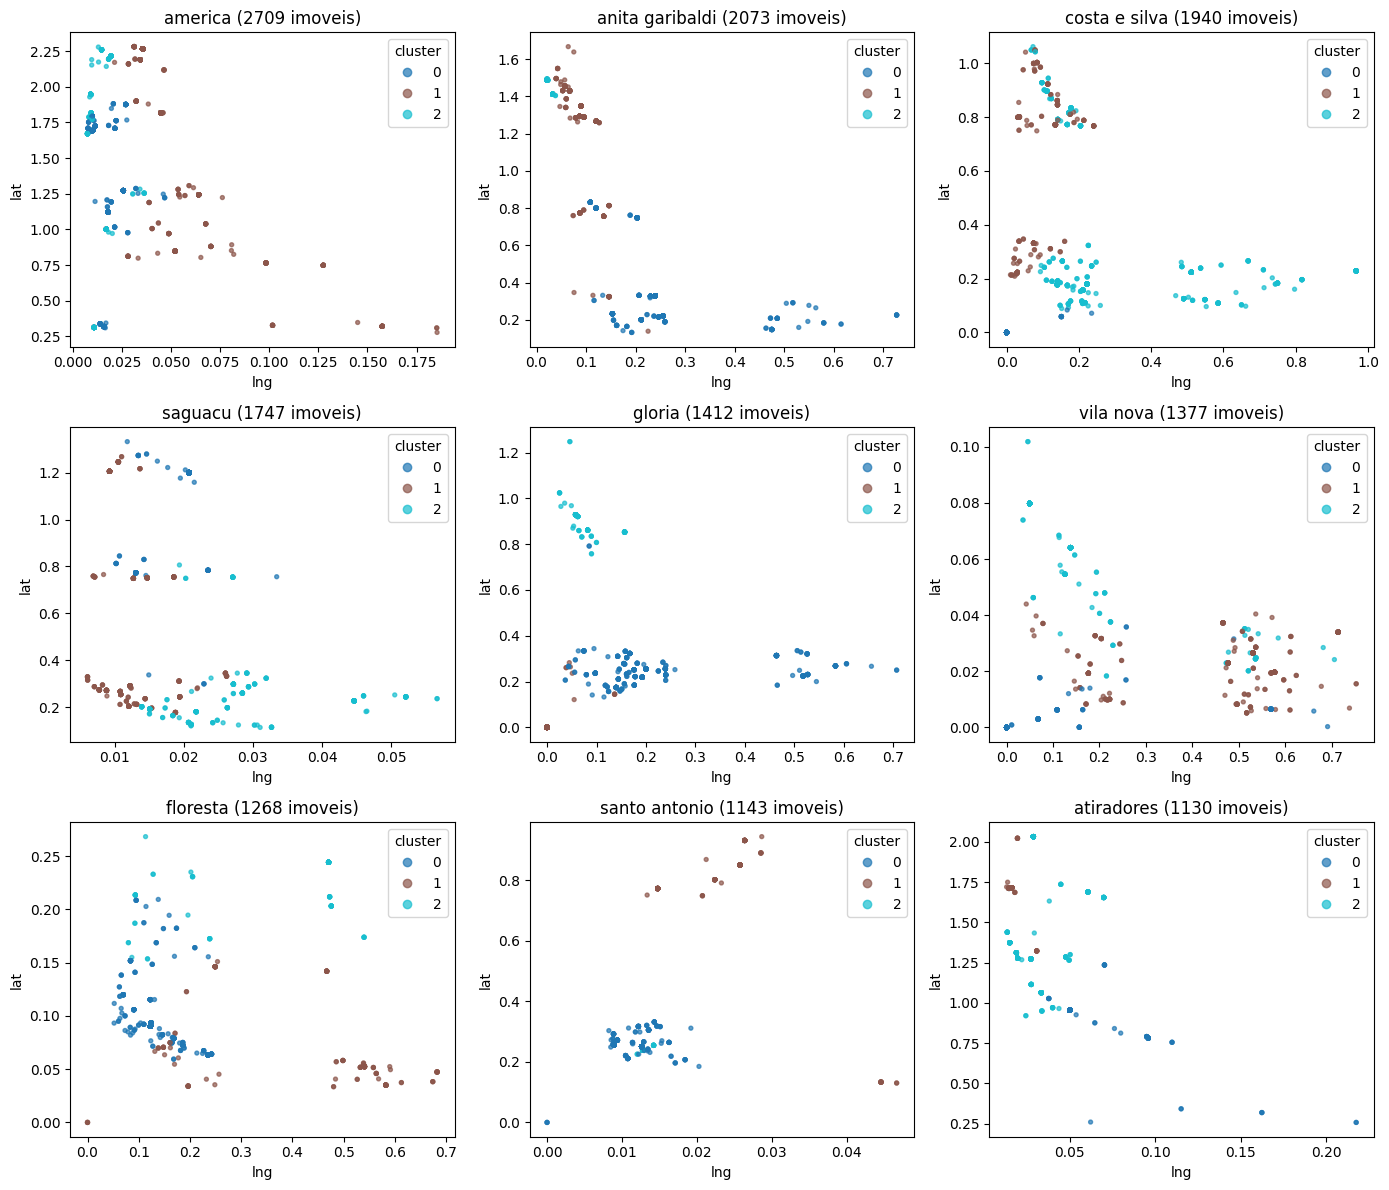

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.concat([train, test], ignore_index=True)

n_bairros = df["bairro"].nunique()
n_clusters = df["bairro_cluster"].nunique()
print(f"{n_bairros} bairros | {n_clusters} clusters no total")
print(df.groupby("bairro")["bairro_cluster"].nunique().describe())

# ── Grid de subplots: um por bairro (top N maiores) ──
top_bairros = df["bairro"].value_counts().head(9).index
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for ax, bairro in zip(axes.flat, top_bairros):
    sub = df[df["bairro"] == bairro]
    cores = sub["bairro_cluster"]
    scatter = ax.scatter(sub["score_escola_publica"], sub["score_hospitais"], c=cores, cmap="tab10",
                         s=8, alpha=0.7)
    ax.set_title(f"{bairro} ({len(sub)} imoveis)")
    ax.set_xlabel("lng")
    ax.set_ylabel("lat")
    ax.legend(*scatter.legend_elements(), title="cluster")

plt.tight_layout()
#plt.savefig("clusters_bairro_grid.png", dpi=150)
plt.show()

In [18]:
df.groupby(["bairro", "bairro_cluster"])['preco_por_m2'].agg(['mean','median', 'count']).head(20)

mean       median  count
bairro          bairro_cluster                                 
adhemar garcia  0               4495.096923  4606.533411    144
                1               3832.420704  3525.641026     15
                2               5750.000000  5750.000000      1
america         0               9458.352386  9670.280255    426
                1               9472.714143  9507.447761   2028
                2               9019.779229  8575.917686    252
anita garibaldi 0               8055.310437  8241.501235   1560
                1               7958.658061  8116.785714    430
                2               8214.201573  8185.849315     83
area rural      0               3943.034529  4593.750000     11
atiradores      0               9636.843097  9670.971429    799
                1               8219.399649  8249.390496     72
                2               9370.487232  9055.118110    259
aventureiro     0               5062.950873  5384.615385    313
                1               4788.779032  4920.145875    126
                2               5068.660118  5357.142857     63
boa vista       0               5167.604106  5284.552846    348
                1               4453.811781  4466.019417     85
                2               4518.470821  5020.000000     40
boehmerwald     0               3766.262479  3913.043478    215

In [ ]:
import folium
df = df.dropna(subset="lat")
df = df.dropna(subset="lat")

mapa = folium.Map(location=[df["lat"].mean(), df["lng"].mean()], zoom_start=12)

cores = ["red", "blue", "green", "purple", "orange"]

for _, row in df.iterrows():
    if pd.isna(row.get("bairro_cluster")):
        continue
    cor = cores[int(row["bairro_cluster"]) % len(cores)]
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=3,
        color=cor,
        fill=True,
        popup=f"{row['bairro']} — cluster {int(row['bairro_cluster'])}",
    ).add_to(mapa)

mapa.show_in_browser()
#mapa

Your map should have been opened in your browser automatically.
Press ctrl+c to return.
